In [1]:
# - Lets see how regularization effects the quality of classification
# - we will use logistic regression with polinomial features and very the regularization parameter C.
# - we will see how regularization effects the seperating border of classifier and 
# intuitively recoganize under and over fitting
# - we will choose regularization parameter to be numerically close to optimal value
#  via cross-validation and grid-search

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
%config InlineBackend.figure_format = "retina"

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import PolynomialFeatures

# What does centered mean

That sentence is describing a common data-preprocessing step called **centering**.

Suppose one of the quality-control test variables originally had values:

| Microchip | Test 1 |
| --------- | ------ |
| A         | 12     |
| B         | 15     |
| C         | 18     |

The mean of Test 1 is:

[
\frac{12+15+18}{3}=15
]

If the data are **centered**, you subtract the mean (15) from every value:

| Microchip | Centered Test 1 |
| --------- | --------------- |
| A         | -3              |
| B         | 0               |
| C         | 3               |

The same process is done separately for each variable (Test 1 and Test 2).

### What does "the average microchip corresponds to a zero value" mean?

After centering:

* A value of **0** means the microchip is exactly at the average for that test.
* A **positive** value means the microchip scored above average.
* A **negative** value means the microchip scored below average.

For example, if a chip has:

* Test 1 = 2.5
* Test 2 = -1.2

then:

* its Test 1 result is 2.5 units above the average Test 1 result,
* its Test 2 result is 1.2 units below the average Test 2 result.

The point **(0, 0)** in the two-dimensional test-result space therefore represents a hypothetical **average microchip**—one whose Test 1 and Test 2 scores are both exactly equal to their respective means.

### Why do this?

Centering makes many statistical methods easier to interpret and compute:

* The origin ((0,0)) becomes the average observation.
* Coefficients in models (e.g., logistic regression) are often easier to interpret.
* Numerical optimization can become more stable.

So in your dataset of 118 microchips, the statement means:

> For each test variable, the mean value has been subtracted from every observation. Therefore, a test value of 0 indicates an average result, positive values indicate above-average results, and negative values indicate below-average results. The point (0,0) represents the average microchip with respect to the two tests.


In [2]:
# dataset of 118 microchips
# there are results of two tests of quality control and information whether the chip went into production
# variables are already centered, ie - column values have had there own mean values subtracted

# DF

DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

#loading data 

data = pd.read_csv(
    DATA_PATH + "microchip_tests.txt",
    header= None,
    names=("test1", "test2", "released")
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   test1     118 non-null    float64
 1   test2     118 non-null    float64
 2   released  118 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB


In [3]:
data.head(5)

,test1,test2,released
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [4]:
data.tail(5)

,test1,test2,released
113,-0.720620,0.538740,0
114,-0.593890,0.494880,0
115,-0.484450,0.999270,0
116,-0.006336,0.999270,0
117,0.632650,-0.030612,0


In [16]:
X = data.iloc[:,:2].values # all cloumns excluding index no 2
y = data.iloc[:, 2].values # only column with index no 2

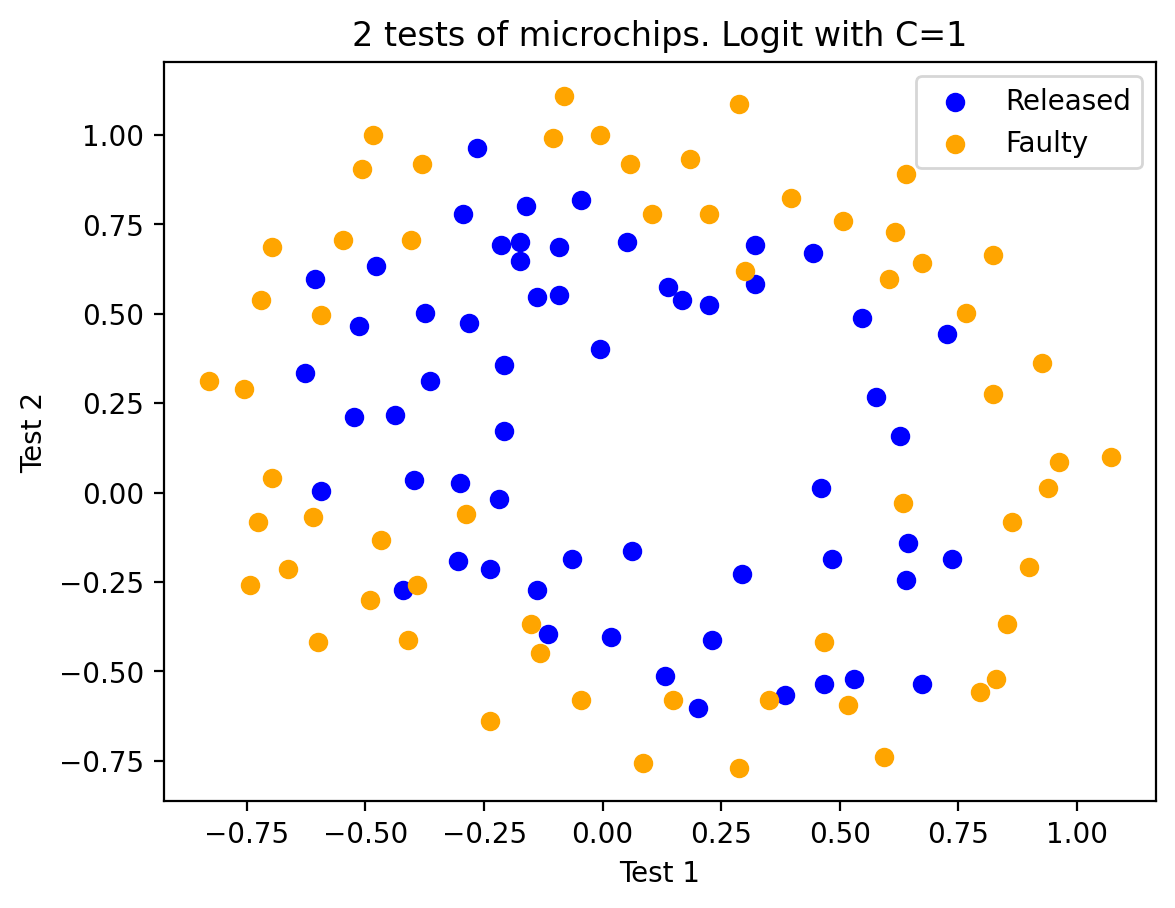

In [6]:
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Released")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Faulty")
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("2 tests of microchips. Logit with C=1")
plt.legend()

In [19]:
# defining a function to display seperating curve for the classifier

def plot_boundary(clf, X, y, grid_step=0.01, poly_featurizer=None):
    x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
    y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
    xx, yy = np.meshgrid(
        np.arange(x_min,x_max, grid_step) , np.arange(y_min, y_max, grid_step)
    )

    # to every point from [x_min, m_max]x[y_min, y_max]
    # we put in correspondence its own color

    Z = clf.predict(poly_featurizer.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, cmap=plt.cm.Paired)


In [13]:
poly = PolynomialFeatures(degree=7)
X_poly = poly.fit_transform(X)

In [14]:
X_poly.shape

(118, 36)

Accuracy on training set: 0.627


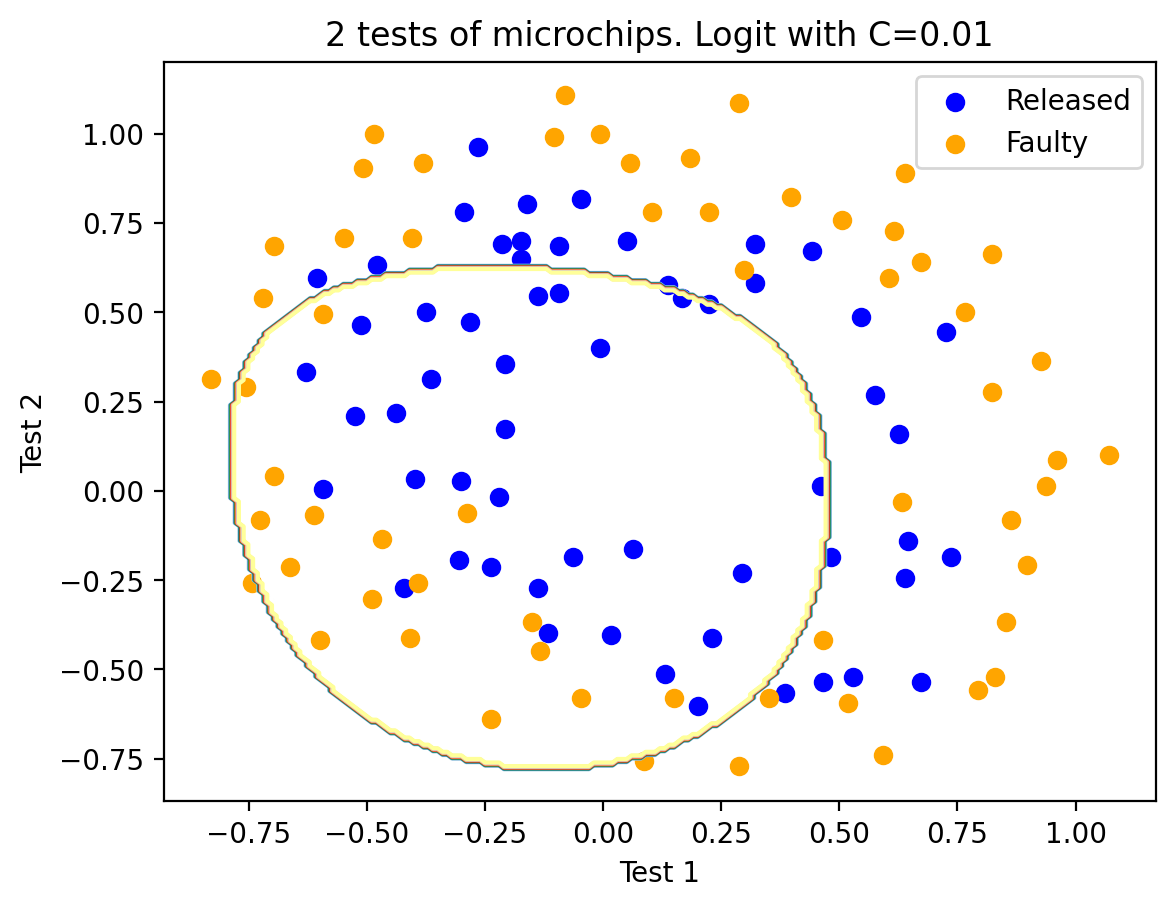

In [20]:
# lets train logistic regression with regularization parameter C = 10 ** -2

C = 1e-2
logit = LogisticRegression(C=C, random_state=17)
logit.fit(X_poly,y)

plot_boundary(logit, X, y,  grid_step=0.01, poly_featurizer=poly)

plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Released")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Faulty")
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("2 tests of microchips. Logit with C=%s" % C)
plt.legend()

print("Accuracy on training set:", round(logit.score(X_poly, y), 3))

Accuracy on training set: 0.831


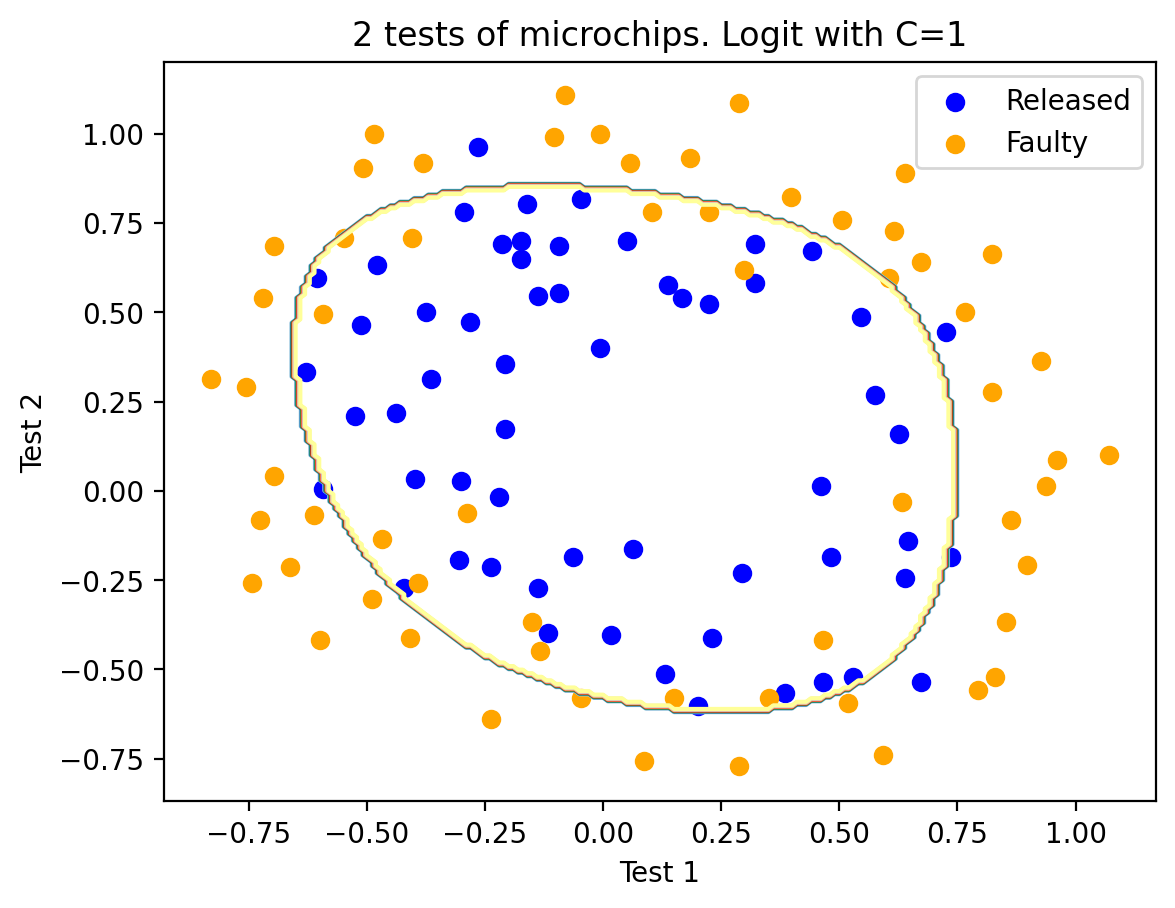

In [21]:
# C = 1

C = 1
logit = LogisticRegression(C=C, random_state=17)
logit.fit(X_poly,y)

plot_boundary(logit, X, y,  grid_step=0.01, poly_featurizer=poly)

plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Released")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Faulty")
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("2 tests of microchips. Logit with C=%s" % C)
plt.legend()

print("Accuracy on training set:", round(logit.score(X_poly, y), 3))

Accuracy on training set: 0.873


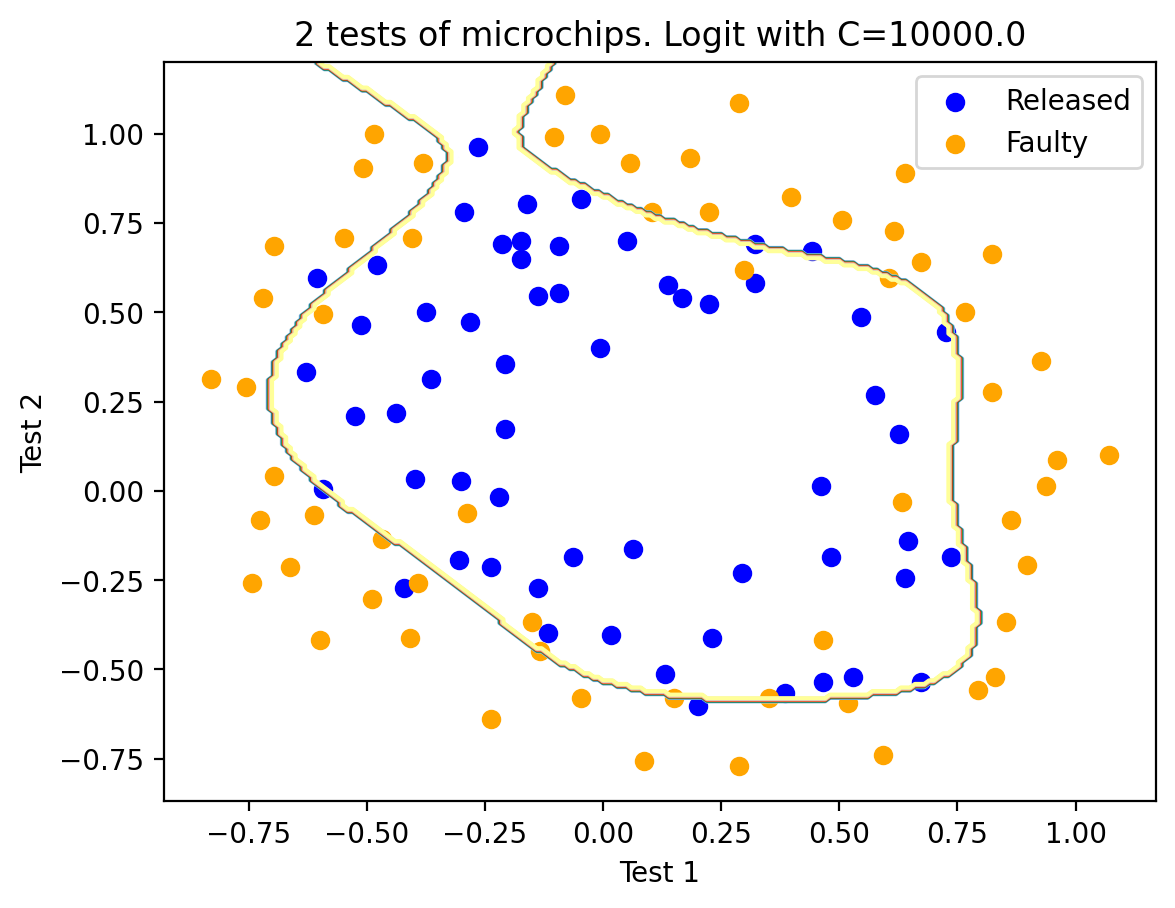

In [22]:
# lets train logistic regression with regularization parameter C = 10 ** 4

C = 1e4
logit = LogisticRegression(C=C, random_state=17)
logit.fit(X_poly,y)

plot_boundary(logit, X, y,  grid_step=0.01, poly_featurizer=poly)

plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Released")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Faulty")
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("2 tests of microchips. Logit with C=%s" % C)
plt.legend()

print("Accuracy on training set:", round(logit.score(X_poly, y), 3))

### Regularization parameter tuning

In [23]:
# done using LogisticRegressionCV 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)
c_values = np.logspace(-2, 3, 500)

logit_searcher = LogisticRegressionCV(Cs=c_values, cv=skf, n_jobs=-1)

logit_searcher.fit(X_poly, y)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",array([1.0000...00000000e+03])
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default.

In [36]:
logit_searcher.C_

array([157.90533145])

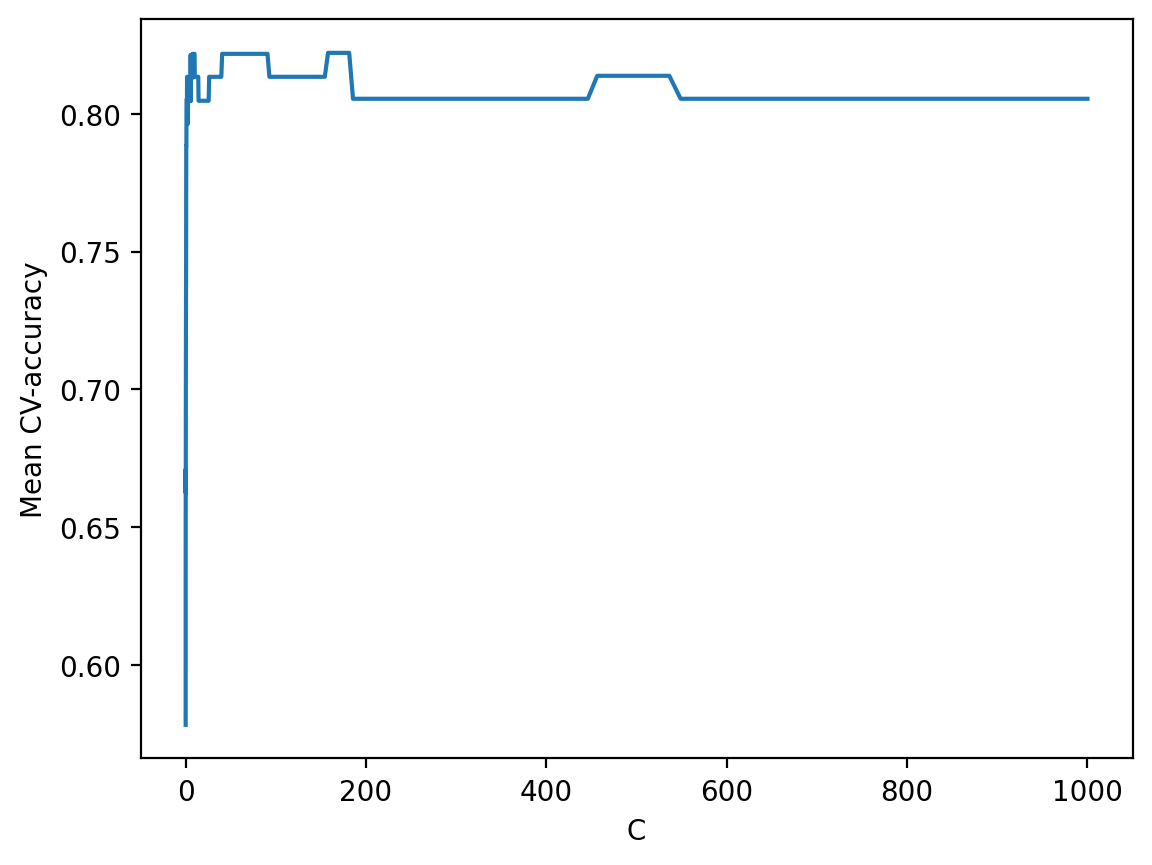

In [34]:
plt.plot(c_values, np.mean(logit_searcher.scores_[1], axis=0))
plt.xlabel("C")
plt.ylabel("Mean CV-accuracy");

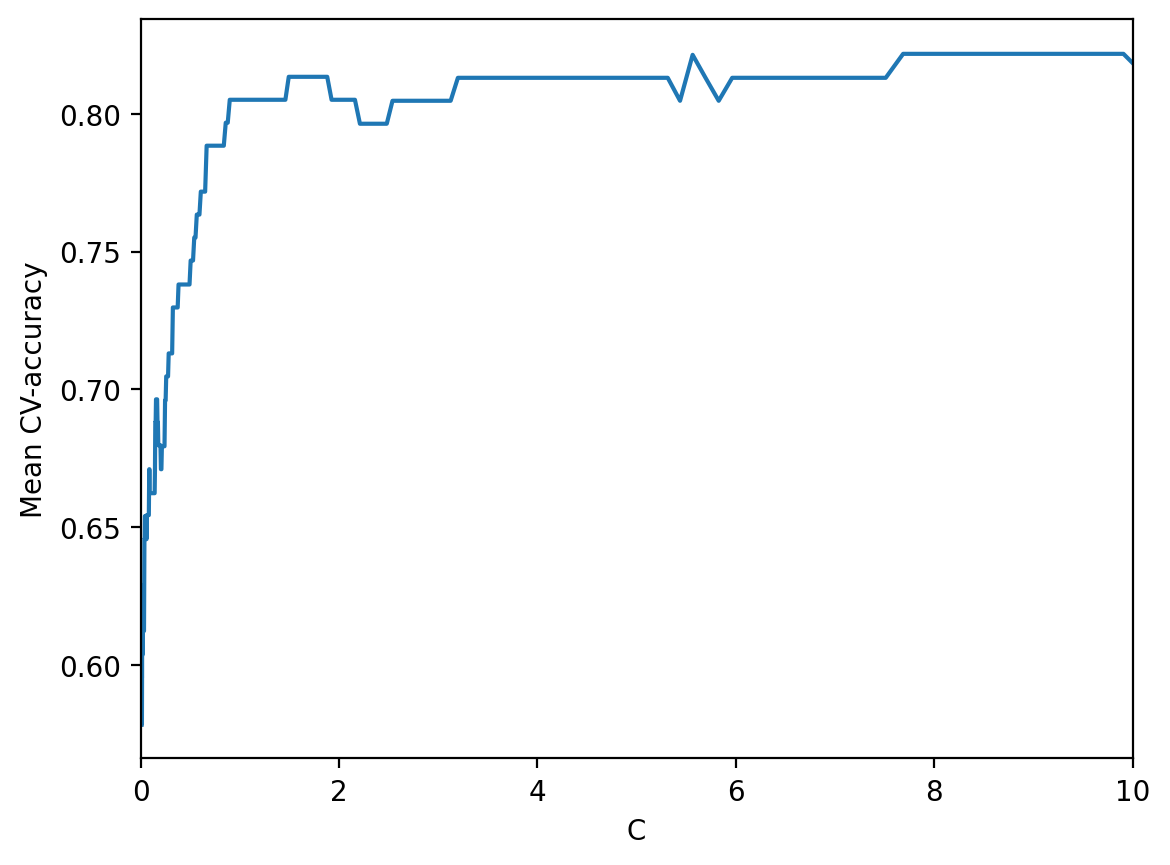

In [44]:
# area with the best value of C
plt.plot(c_values, np.mean(logit_searcher.scores_[1], axis=0))
plt.xlabel("C")
plt.ylabel("Mean CV-accuracy")
plt.xlim((0, 10));

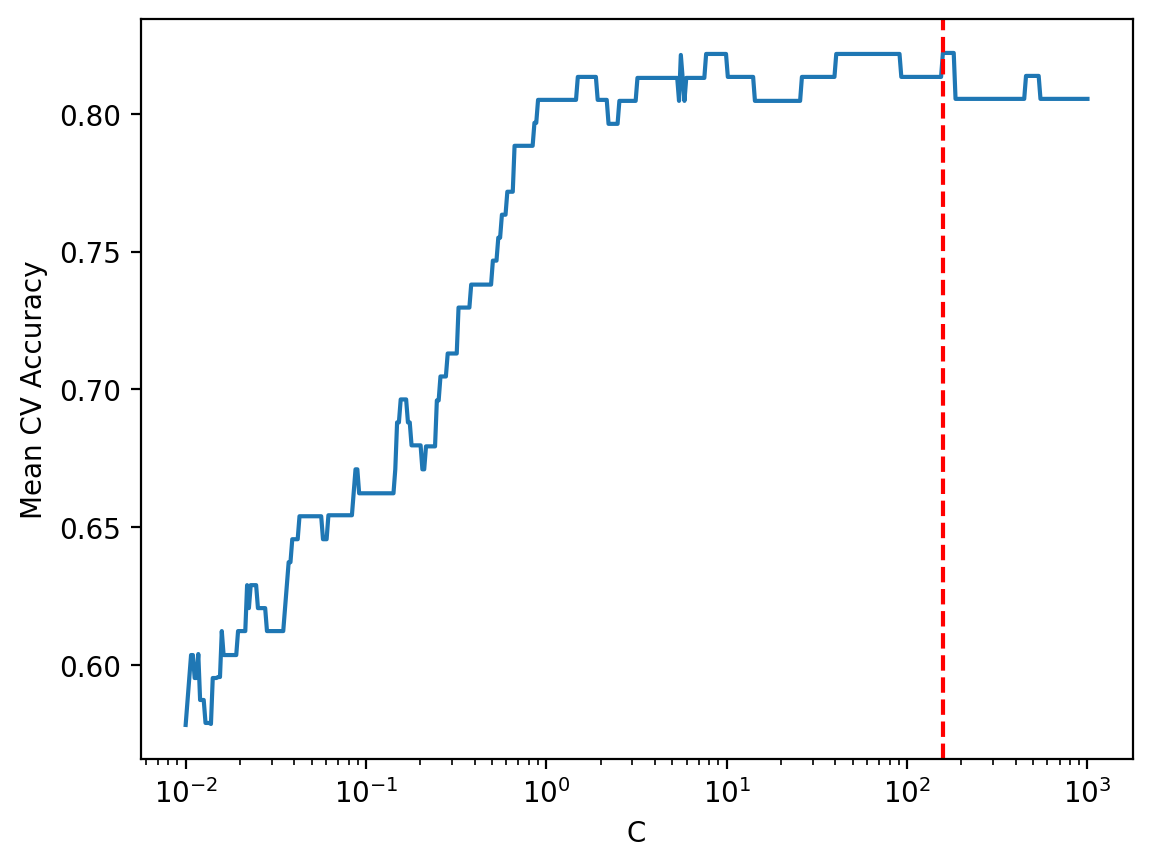

In [37]:
mean_scores = np.mean(logit_searcher.scores_[1], axis=0)

plt.plot(c_values, mean_scores)
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Accuracy')
plt.axvline(logit_searcher.C_[0], color='red', linestyle='--')
plt.show()

In [38]:
mean_scores = np.mean(logit_searcher.scores_[1], axis=0)

best_idx = np.argmax(mean_scores)

print(c_values[best_idx])
print(mean_scores[best_idx])

157.90533144741758
0.8221014492753623
